In [9]:
import pandas as pd

df = pd.read_csv("cleaned_data.csv")

X = df.drop(columns=['target'])
y = df['target']

In [11]:
import joblib

model_package = joblib.load("final_model.pkl")

best_model = model_package["model"]
threshold = model_package["threshold"]
features = model_package["features"]
# ============================================================
# RECREATE FEATURE ENGINEERING (CRITICAL FIX)
# ============================================================

# Avoid division by zero
df['meds_x_procedures'] = df['num_medications'] * df['num_procedures']
df['med_per_diagnosis'] = df['num_medications'] / (df['number_diagnoses'] + 1)
df['procedures_per_day'] = df['num_procedures'] / (df['time_in_hospital'] + 1)
df['lab_ratio'] = df['num_lab_procedures'] / (df['time_in_hospital'] + 1)

# Now create X
X = df.drop(columns=['target'])
# Ensure same column order
X = X[features]

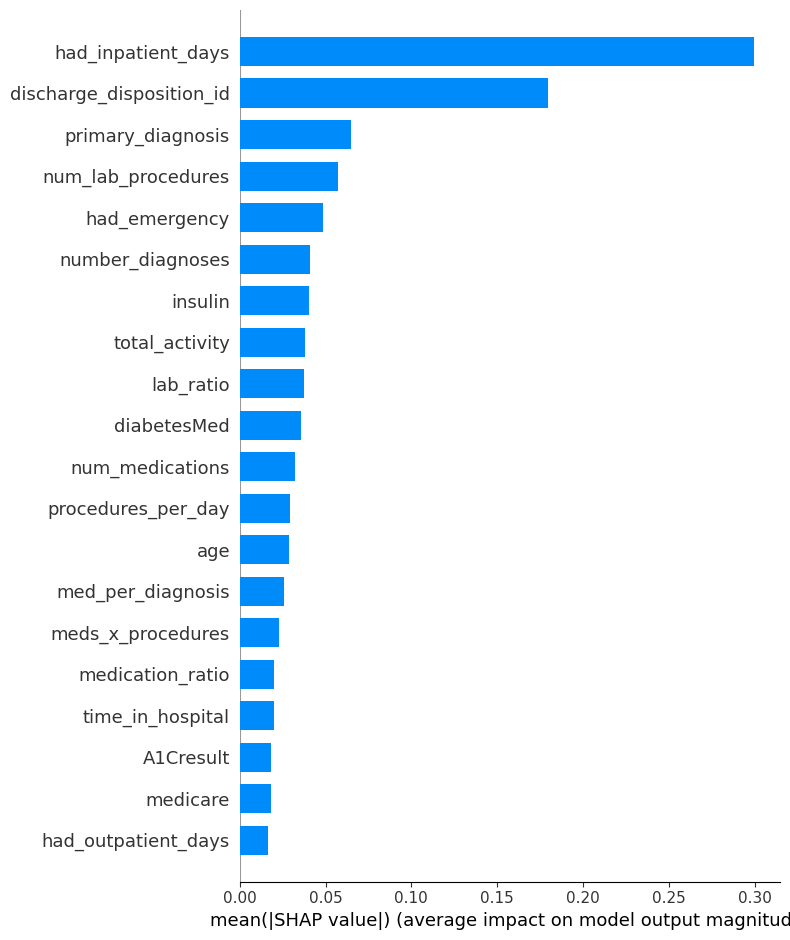

In [12]:
import shap

explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X)

shap.summary_plot(shap_values, X, plot_type="bar")

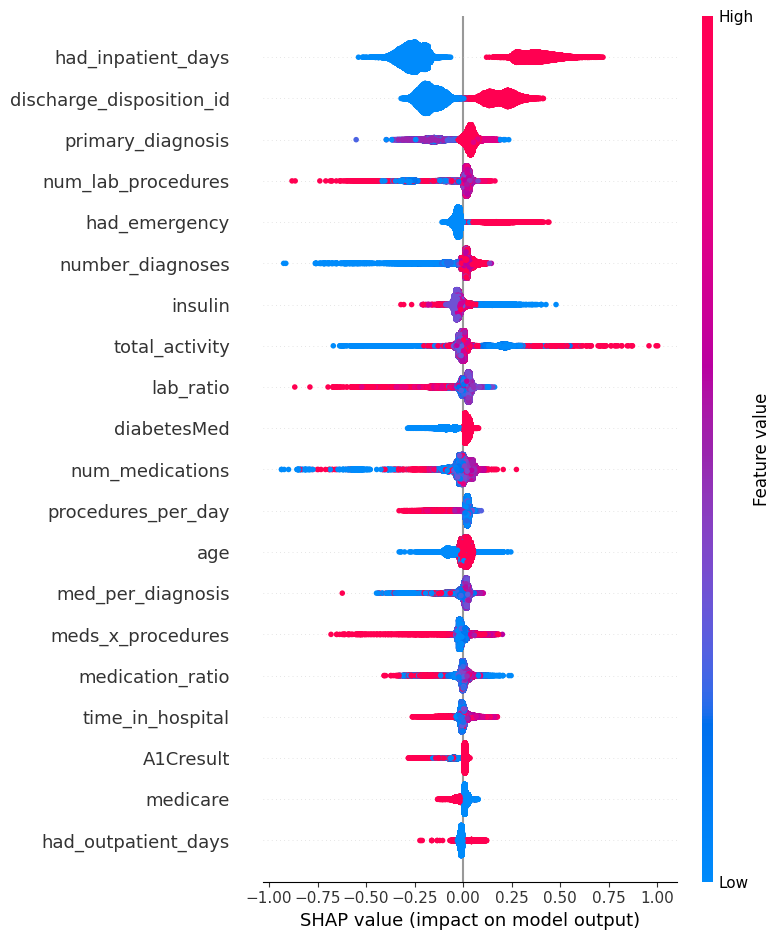

In [13]:
shap.summary_plot(shap_values, X)

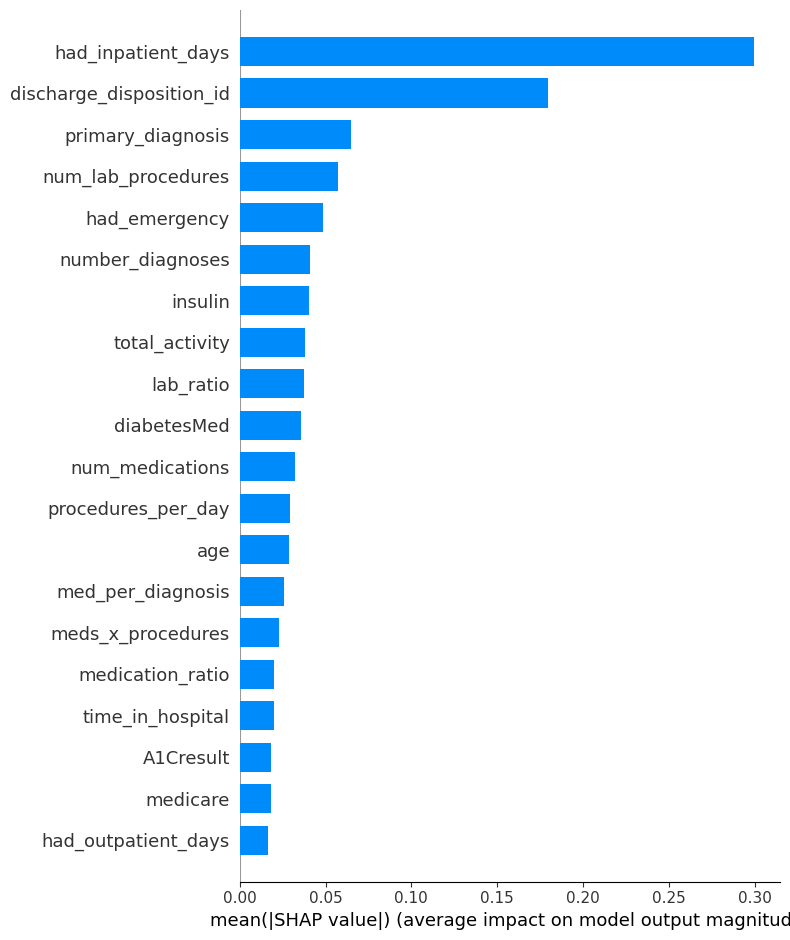

In [14]:
shap.summary_plot(shap_values, X, plot_type="bar")